## Proyecto de Análisis de Riesgo Crediticio
Curso: Data Science II - Machine Learning para la Ciencia de Datos

Alumno: Martínez German

Profesor: Jorge Ruiz

Tutor: Carlos Davoli

Comision: 77745


### Abstract
Este proyecto analiza el riesgo crediticio de solicitantes de préstamos utilizando el German Credit Dataset. El objetivo es identificar los factores que influyen en la probabilidad de incumplimiento, con el fin de mejorar la toma de decisiones en la aprobación de créditos.

A través de análisis exploratorio de datos y visualizaciones, se evalúan variables financieras, demográficas y de comportamiento crediticio para detectar patrones asociados al riesgo. Los resultados permiten comprender qué perfiles presentan mayor probabilidad de default y qué características funcionan como indicadores de solvencia.

Este análisis aporta valor a instituciones financieras, analistas de riesgo y áreas de crédito al proporcionar evidencia basada en datos para optimizar políticas de evaluación crediticia.

## Preguntas de análisis

1. ¿Qué factores influyen en el riesgo crediticio?

2. ¿Existe relación entre edad y riesgo?

3. ¿Los montos más altos implican mayor riesgo?

4. ¿La duración del crédito influye en el riesgo?

5. ¿El historial crediticio afecta la probabilidad de incumplimiento?


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [3]:
path = "../data/raw/german.data"
df = pd.read_csv(path, sep=" ", header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [4]:
columns = [
    "estado_de_cuenta_corriente", "meses_de_duracion", "historial_de_credito", "proposito",
    "monto_de_credito", "cuentas_de_ahorro", "empleo_desde", "tasa_de_pago_a_plazos",
    "estado_personal_genero", "otros_deudores", "residencia_desde", "propietario",
    "edad", "otros_planes_de_pago", "alojamiento", "creditos_existentes",
    "trabajo", "dependencias", "telefono", "trabajador_extranjero", "riesgo_crediticio"
]

df.columns = columns
df.head()

,estado_de_cuenta_corriente,meses_de_duracion,historial_de_credito,proposito,monto_de_credito,cuentas_de_ahorro,empleo_desde,tasa_de_pago_a_plazos,estado_personal_genero,otros_deudores,...,propietario,edad,otros_planes_de_pago,alojamiento,creditos_existentes,trabajo,dependencias,telefono,trabajador_extranjero,riesgo_crediticio
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [5]:
df.shape

(1000, 21)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   estado_de_cuenta_corriente  1000 non-null   str  
 1   meses_de_duracion           1000 non-null   int64
 2   historial_de_credito        1000 non-null   str  
 3   proposito                   1000 non-null   str  
 4   monto_de_credito            1000 non-null   int64
 5   cuentas_de_ahorro           1000 non-null   str  
 6   empleo_desde                1000 non-null   str  
 7   tasa_de_pago_a_plazos       1000 non-null   int64
 8   estado_personal_genero      1000 non-null   str  
 9   otros_deudores              1000 non-null   str  
 10  residencia_desde            1000 non-null   int64
 11  propietario                 1000 non-null   str  
 12  edad                        1000 non-null   int64
 13  otros_planes_de_pago        1000 non-null   str  
 14  alojamiento         

In [7]:
df.describe()

,meses_de_duracion,monto_de_credito,tasa_de_pago_a_plazos,residencia_desde,edad,creditos_existentes,dependencias,riesgo_crediticio
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,1.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,2.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000


El cliente promedio es un adulto joven que solicita créditos de mediano monto y duración, lo cual sugiere financiamiento para consumo o bienes durables.

In [8]:
df["riesgo_crediticio"].value_counts()

riesgo_crediticio
1    700
2    300
Name: count, dtype: int64

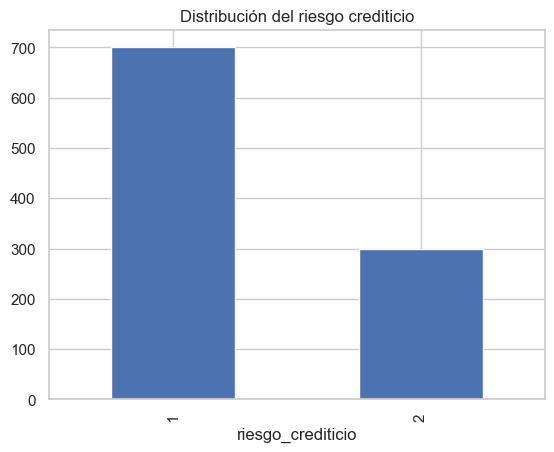

In [9]:
df["riesgo_crediticio"].value_counts().plot(kind="bar")
plt.title("Distribución del riesgo crediticio")
plt.show()

El dataset presenta un desbalance en la variable objetivo, donde el 70% de los clientes corresponden a bajo riesgo crediticio y el 30% a alto riesgo. Este comportamiento es consistente con escenarios reales del sistema financiero.

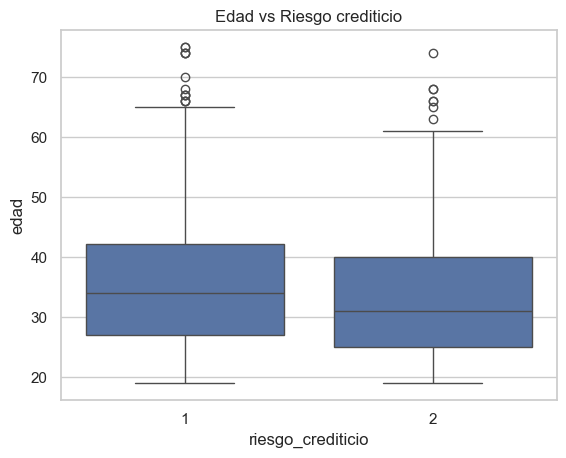

In [10]:
sns.boxplot(x="riesgo_crediticio", y="edad", data=df)
plt.title("Edad vs Riesgo crediticio")
plt.show()

Se observa que los clientes con mayor riesgo crediticio tienden a ser ligeramente más jóvenes, lo que podría estar asociado a menor estabilidad financiera o menor historial crediticio.

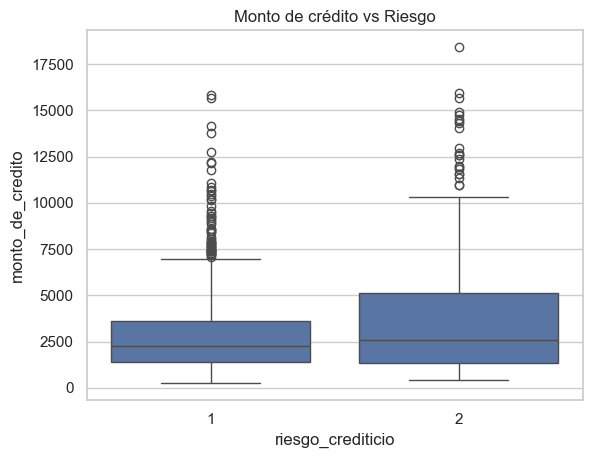

In [11]:
sns.boxplot(x="riesgo_crediticio", y="monto_de_credito", data=df)
plt.title("Monto de crédito vs Riesgo")
plt.show()

Los solicitantes clasificados como de alto riesgo presentan montos de crédito significativamente mayores y mayor variabilidad, lo que sugiere una relación positiva entre el tamaño del préstamo y la probabilidad de incumplimiento.

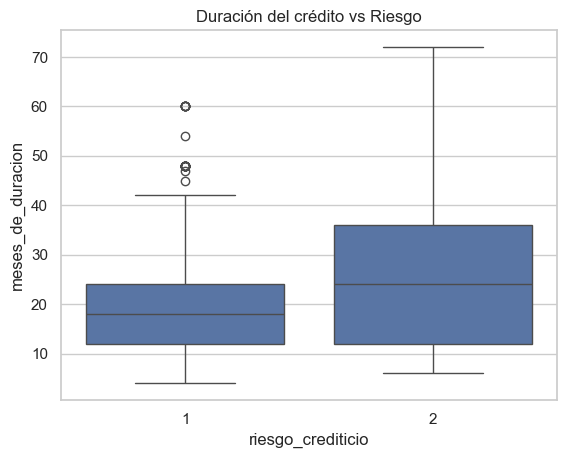

In [12]:
sns.boxplot(x="riesgo_crediticio", y="meses_de_duracion", data=df)
plt.title("Duración del crédito vs Riesgo")
plt.show()

Los créditos de mayor duración se asocian con un incremento del riesgo crediticio, posiblemente debido al aumento de la incertidumbre a largo plazo.

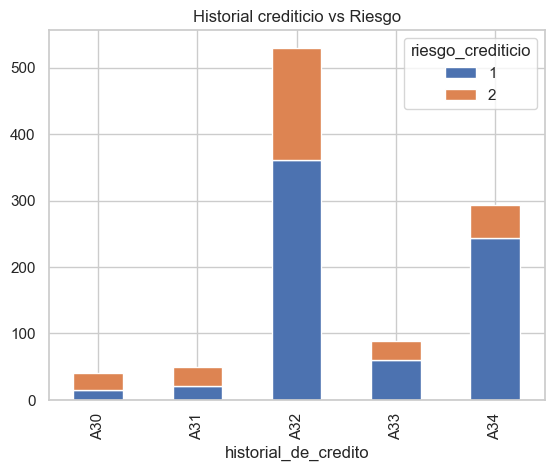

In [13]:
pd.crosstab(df["historial_de_credito"], df["riesgo_crediticio"]).plot(kind="bar", stacked=True)
plt.title("Historial crediticio vs Riesgo")
plt.show()

El historial crediticio emerge como una de las variables más influyentes en la evaluación del riesgo, observándose que categorías con antecedentes negativos presentan mayor proporción de incumplimiento.

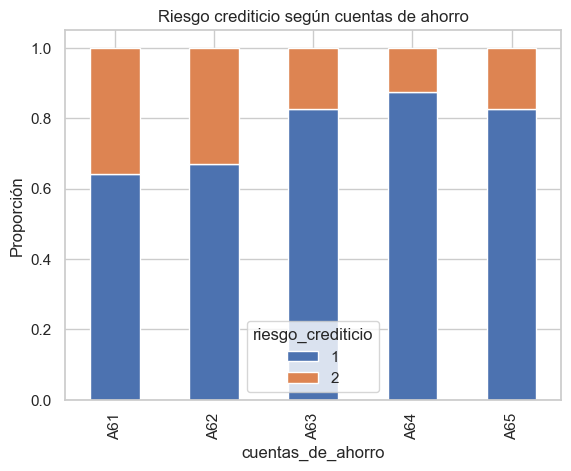

In [14]:
pd.crosstab(df["cuentas_de_ahorro"], df["riesgo_crediticio"], normalize="index").plot(kind="bar", stacked=True)

plt.title("Riesgo crediticio según cuentas de ahorro")
plt.ylabel("Proporción")
plt.show()

Los clientes con mayores niveles de ahorro presentan menor riesgo crediticio, lo que sugiere que la liquidez disponible funciona como un factor de protección frente al incumplimiento.

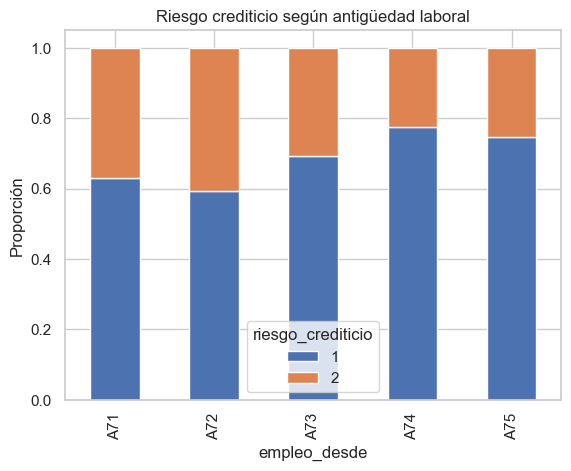

In [15]:
pd.crosstab(df["empleo_desde"], df["riesgo_crediticio"], normalize="index").plot(kind="bar", stacked=True)

plt.title("Riesgo crediticio según antigüedad laboral")
plt.ylabel("Proporción")
plt.show()

La estabilidad laboral muestra una relación inversa con el riesgo crediticio: a mayor antigüedad en el empleo, menor probabilidad de incumplimiento.

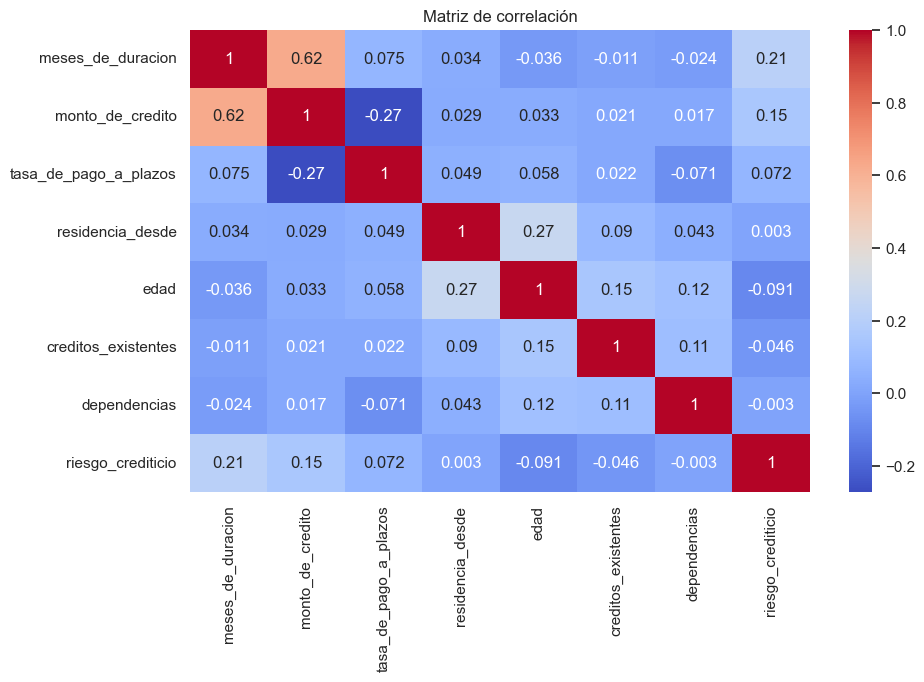

In [16]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

El riesgo crediticio presenta mayor asociación con la duración del crédito y el monto solicitado, lo que sugiere que exposiciones más prolongadas y montos elevados incrementan la probabilidad de incumplimiento


## Hipótesis generales

## Monto del crédito y riesgo

### Hipótesis:
Los clientes que solicitan montos de crédito más altos presentan mayor riesgo de incumplimiento.

### Justificación:
Créditos más grandes implican mayor carga financiera y mayor probabilidad de default.

### Resultado observado: 
Los clientes con mayor riesgo presentan montos medianos y máximos más elevados.

## Duración del crédito y riesgo

### Hipótesis:
Los créditos con mayor duración presentan mayor riesgo de incumplimiento.

### Justificación:
A mayor plazo, mayor exposición al riesgo económico y cambios en la capacidad de pago.

### Resultado observado: 
Los créditos de mayor duración están asociados a clientes de mayor riesgo

## Historial crediticio como predictor

### Hipótesis:
Un historial crediticio negativo aumenta significativamente el riesgo de incumplimiento.

### Justificación:
El comportamiento pasado es uno de los mejores predictores del comportamiento futuro.

### Resultado observado: 
Categorías con historial negativo presentan mayor proporción de clientes riesgosos.

## Nivel de ahorro y riesgo

### Hipótesis:
Los clientes con mayores niveles de ahorro presentan menor riesgo crediticio.

### Justificación:
El ahorro refleja solvencia financiera y capacidad de afrontar imprevistos.

### Resultado observado: 
A mayor nivel de ahorro, menor proporción de incumplimiento.

## Estabilidad laboral y riesgo

### Hipótesis:
Los clientes con mayor antigüedad laboral presentan menor riesgo de incumplimiento.

### Justificación:
La estabilidad laboral implica ingresos más predecibles y menor vulnerabilidad económica.

### Resultado observado: 
Mayor antigüedad laboral se asocia con menor proporción de riesgo.

## Edad y riesgo crediticio

### Hipótesis:
Los clientes de mayor edad presentan menor riesgo crediticio.

### Justificación:
Mayor estabilidad financiera y experiencia en gestión de deudas.

### Resultado observado: 
Se observa una leve correlación negativa entre edad y riesgo.

## Indicador global del análisis
El riesgo crediticio está influenciado principalmente por variables financieras (monto, duración, ahorro), historial crediticio y estabilidad laboral, lo que sugiere que el perfil de solvencia del cliente es un factor determinante en la probabilidad de incumplimiento.

In [17]:
df_clean = df.copy()

In [18]:
df_clean.head()

,estado_de_cuenta_corriente,meses_de_duracion,historial_de_credito,proposito,monto_de_credito,cuentas_de_ahorro,empleo_desde,tasa_de_pago_a_plazos,estado_personal_genero,otros_deudores,...,propietario,edad,otros_planes_de_pago,alojamiento,creditos_existentes,trabajo,dependencias,telefono,trabajador_extranjero,riesgo_crediticio
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [48]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
#  variable objetivo
# Originalmente:
# 1 = Buen pagador (bajo riesgo)
# 2 = Mal pagador (alto riesgo)
# Convertimos a formato estándar de clasificación:
# 0 = buen pagador
# 1 = mal pagador (default)
df_clean['riesgo_crediticio'] = df_clean['riesgo_crediticio'].map({1: 0, 2: 1})
# 1.2 Separación de características (X) y variable objetivo (y)
X = df_clean.drop('riesgo_crediticio', axis=1)
y = df_clean['riesgo_crediticio']
print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (1000, 20)
Dimensiones de y: (1000,)


In [ ]:
# identificando variables categóricas y numéricas
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Variables categóricas:", cat_cols)
print("Variables numéricas:", num_cols)

Variables categóricas: ['estado_de_cuenta_corriente', 'historial_de_credito', 'proposito', 'cuentas_de_ahorro', 'empleo_desde', 'estado_personal_genero', 'otros_deudores', 'propietario', 'otros_planes_de_pago', 'alojamiento', 'trabajo', 'telefono', 'trabajador_extranjero']
Variables numéricas: ['meses_de_duracion', 'monto_de_credito', 'tasa_de_pago_a_plazos', 'residencia_desde', 'edad', 'creditos_existentes', 'dependencias']


C:\Users\Ger\AppData\Local\Temp\ipykernel_33928\489096729.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object']).columns.tolist()


In [ ]:
# variables categóricas
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print("Dimensiones después del encoding:", X_encoded.shape)

Dimensiones después del encoding: (1000, 48)


In [ ]:
#  entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_encoded,y,
test_size=0.2,random_state=42,stratify=y)
print("Dimensiones de entrenamiento:", X_train.shape)
print("Dimensiones de prueba:", X_test.shape)

Dimensiones de entrenamiento: (800, 48)
Dimensiones de prueba: (200, 48)


In [ ]:
# 1.6 Estandarización de variables numéricas

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print("Dimensiones de X_train_scaled:", X_train_scaled.shape)
print("Dimensiones de X_test_scaled:", X_test_scaled.shape)

Dimensiones de X_train_scaled: (800, 48)
Dimensiones de X_test_scaled: (200, 48)


## Ingeniería de atributos y preparación de datos
En esta etapa se prepara el dataset para el entrenamiento de modelos de Machine Learning.
Las principales tareas incluyen:
- Transformación de la variable objetivo
- Identificación de variables categóricas y numéricas
- Codificación de variables categóricas
- División en datos de entrenamiento y prueba
- Estandarización de variables numéricas

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# modelo
log_model = LogisticRegression(max_iter=1000)
# entrenamiento del modelo
log_model.fit(X_train_scaled, y_train)
# predicciones sobre el set de prueba
y_pred_log = log_model.predict(X_test_scaled)
# probabilidades de predicción
y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]
# evaluar el modelo
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_log))

print("ROC AUC:", roc_auc_score(y_test, y_prob_log))

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.82      0.89      0.85       140
           1       0.67      0.53      0.59        60

    accuracy                           0.78       200
   macro avg       0.74      0.71      0.72       200
weighted avg       0.77      0.78      0.77       200

ROC AUC: 0.8039285714285714


### Evaluación del modelo de Regresión Logística

El modelo de regresión logística fue entrenado para predecir el riesgo crediticio de los solicitantes utilizando las variables financieras y demográficas disponibles en el dataset.

Los resultados muestran una **precisión global (accuracy) del 78%**, lo que indica que el modelo logra clasificar correctamente una proporción significativa de los clientes.

Al analizar las métricas por clase, se observa que el modelo identifica correctamente a la mayoría de los **clientes de bajo riesgo**, con un recall de 0.89. Sin embargo, la detección de **clientes de alto riesgo** presenta un recall menor (0.53), lo que indica que algunos casos de incumplimiento potencial no son identificados por el modelo.

La métrica **ROC AUC alcanza un valor de 0.80**, lo que sugiere una buena capacidad del modelo para distinguir entre clientes de bajo y alto riesgo crediticio.

En general, la regresión logística proporciona un modelo base sólido para el problema de clasificación. En las siguientes secciones se explorarán modelos más avanzados, como Random Forest y XGBoost, con el objetivo de mejorar la capacidad predictiva del sistema.

### Matriz de Confusión

La matriz de confusión permite evaluar con mayor detalle el desempeño del modelo, mostrando cuántas predicciones fueron correctas y cuántas incorrectas para cada clase.

En el contexto del riesgo crediticio, esta matriz permite observar cuántos clientes de alto riesgo fueron correctamente identificados por el modelo y cuántos casos fueron clasificados de forma incorrecta.

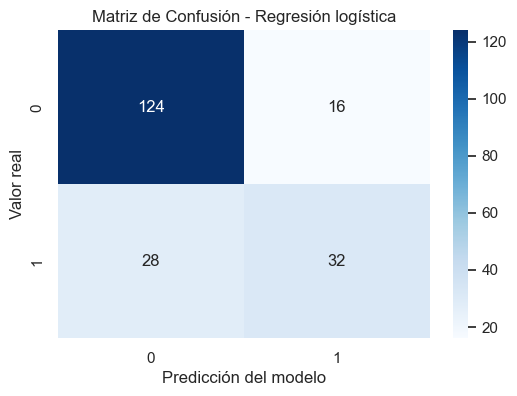

In [46]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# matriz de confusión
cm = confusion_matrix(y_test, y_pred_log)
# Visualización
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión - Regresión logística")
plt.xlabel("Predicción del modelo")
plt.ylabel("Valor real")

plt.show()

### Curva ROC

La curva ROC (Receiver Operating Characteristic) permite evaluar la capacidad del modelo para distinguir entre clientes de bajo y alto riesgo crediticio.

El área bajo la curva (ROC AUC) mide el poder discriminatorio del modelo. Valores cercanos a 1 indican un modelo con alta capacidad de separación entre clases, mientras que valores cercanos a 0.5 indican un modelo equivalente al azar.

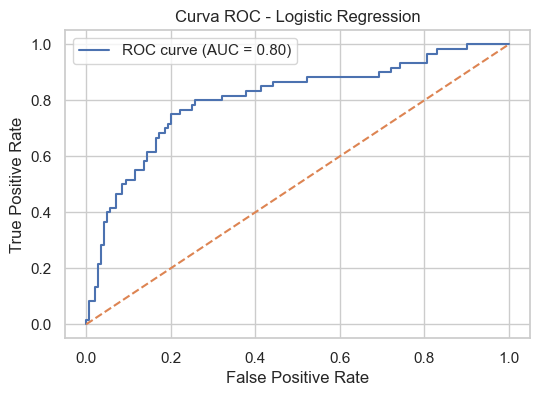

In [45]:
from sklearn.metrics import roc_curve, auc
# curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_log)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Logistic Regression")
plt.legend()
plt.show()

## Modelo 2: Random Forest

Random Forest es un modelo de aprendizaje basado en árboles de decisión que utiliza múltiples árboles entrenados sobre diferentes subconjuntos de datos.

Este enfoque permite capturar relaciones no lineales entre variables y suele mejorar el rendimiento predictivo en comparación con modelos lineales como la regresión logística.

En este proyecto se entrena un modelo Random Forest para comparar su desempeño con el modelo base de regresión logística.

In [39]:
from sklearn.ensemble import RandomForestClassifier

# Crear modelo
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
# entrenar modelo
rf_model.fit(X_train_scaled, y_train)
# predicciones
y_pred_rf = rf_model.predict(X_test_scaled)
# Probabilidad
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:,1]
# evaluación
print("Reporte de clasificación RandomForest:")
print(classification_report(y_test, y_pred_rf))

print("ROC AUC:", roc_auc_score(y_test, y_prob_rf))

Reporte de clasificación RandomForest:
              precision    recall  f1-score   support

           0       0.77      0.94      0.85       140
           1       0.72      0.35      0.47        60

    accuracy                           0.77       200
   macro avg       0.75      0.65      0.66       200
weighted avg       0.76      0.77      0.74       200

ROC AUC: 0.8018452380952382


### Evaluación del modelo Random Forest

El modelo Random Forest fue entrenado para comparar su desempeño con el modelo base de regresión logística.

Los resultados muestran una **precisión global (accuracy) del 77%**, similar a la obtenida con la regresión logística. Asimismo, el valor de **ROC AUC cercano a 0.80** indica que el modelo mantiene una buena capacidad para diferenciar entre clientes de bajo y alto riesgo crediticio.

Sin embargo, al analizar las métricas por clase se observa que el modelo presenta un **recall menor para la clase de alto riesgo (0.35)** en comparación con la regresión logística. Esto implica que el modelo detecta una menor proporción de clientes potencialmente riesgosos.

Por otro lado, el modelo muestra un **alto recall para clientes de bajo riesgo (0.94)**, lo que indica una buena capacidad para identificar clientes seguros.

En conjunto, los resultados sugieren que el modelo Random Forest presenta un desempeño general similar al modelo base, aunque con menor capacidad para detectar casos de incumplimiento. En las siguientes etapas se explorará la optimización de hiperparámetros para mejorar el rendimiento del modelo.

In [40]:
#  variables importantes

import pandas as pd

importances = rf_model.feature_importances_
feature_names = X_train_scaled.columns
feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})
feature_importance_df = feature_importance_df.sort_values(by="importance", ascending=False)
feature_importance_df.head(10)

,feature,importance
1,monto_de_credito,0.112921
0,meses_de_duracion,0.088872
4,edad,0.087616
9,estado_de_cuenta_corriente_A14,0.066429
2,tasa_de_pago_a_plazos,0.042320
3,residencia_desde,0.036524
13,historial_de_credito_A34,0.025198
40,otros_planes_de_pago_A143,0.023982
7,estado_de_cuenta_corriente_A12,0.022575
26,cuentas_de_ahorro_A65,0.021689


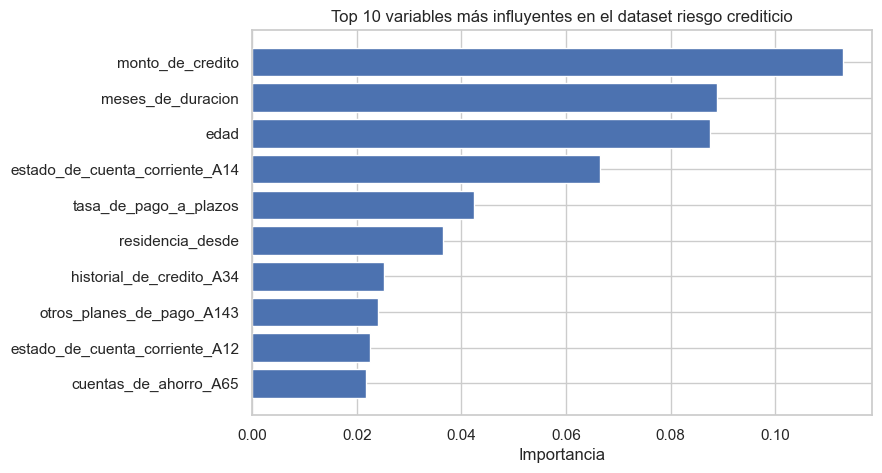

In [41]:
# ranking sobre la importancia de variables

import matplotlib.pyplot as plt

top_features = feature_importance_df.head(10)
plt.figure(figsize=(8,5))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Importancia")
plt.title("Top 10 variables más influyentes en el dataset riesgo crediticio")
plt.gca().invert_yaxis()
plt.show()

### Importancia de variables en el modelo Random Forest

El modelo Random Forest permite analizar qué variables tienen mayor influencia en la predicción del riesgo crediticio.

Los resultados muestran que las variables más importantes están relacionadas principalmente con características financieras del préstamo y del perfil del cliente.

Entre las variables más influyentes se destacan el **monto del crédito**, la **duración del préstamo** y la **edad del solicitante**, lo cual coincide con los hallazgos obtenidos en el análisis exploratorio de datos.

Asimismo, variables relacionadas con el estado financiero del cliente, como el **estado de la cuenta corriente** y la **tasa de pago a plazos**, también muestran una contribución significativa en la predicción del riesgo.

Estos resultados refuerzan la idea de que el riesgo crediticio está fuertemente asociado a la magnitud del préstamo, la estabilidad financiera del cliente y su capacidad de pago.

## Optimización del modelo Random Forest

Para mejorar el desempeño del modelo Random Forest se aplica una técnica de optimización de hiperparámetros utilizando **GridSearchCV**.

Esta técnica permite evaluar diferentes combinaciones de parámetros del modelo mediante validación cruzada, con el objetivo de encontrar la configuración que maximiza el rendimiento predictivo.

En este caso se optimizan parámetros clave del modelo como el número de árboles, la profundidad máxima de los árboles y el número mínimo de muestras necesarias para dividir un nodo.

In [42]:
from sklearn.model_selection import GridSearchCV

# hiperparámetros a probar
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10]
}
# modelo base
rf = RandomForestClassifier(random_state=42)
# configurar GridSearch
grid_search = GridSearchCV(estimator=rf,param_grid=param_grid,cv=5,scoring="roc_auc",n_jobs=-1)
# entrenar GridSearch
grid_search.fit(X_train_scaled, y_train)
# Mejores parámetros
print("Mejores parámetros encontrados:")
print(grid_search.best_params_)

Mejores parámetros encontrados:
{'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}


In [44]:
# mejor modelo encontrado
best_rf = grid_search.best_estimator_
# predicciones
y_pred_best_rf = best_rf.predict(X_test_scaled)
# probabilidades
y_prob_best_rf = best_rf.predict_proba(X_test_scaled)[:,1]
# evaluación
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_best_rf))
print("ROC AUC:", roc_auc_score(y_test, y_prob_best_rf))

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.78      0.96      0.86       140
           1       0.79      0.38      0.52        60

    accuracy                           0.79       200
   macro avg       0.79      0.67      0.69       200
weighted avg       0.79      0.79      0.76       200

ROC AUC: 0.7942857142857143


## Optimización del modelo Random Forest

En esta etapa se utilizó **GridSearchCV** para buscar automáticamente la mejor combinación de hiperparámetros para el modelo Random Forest.

Los parámetros evaluados fueron:

- `n_estimators`: cantidad de árboles en el bosque
- `max_depth`: profundidad máxima de cada árbol
- `min_samples_split`: cantidad mínima de muestras necesarias para dividir un nodo

### Mejores parámetros encontrados

```
{'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}
```

Esto significa que el mejor modelo encontrado fue:

- 200 árboles
- profundidad sin límite
- mínimo 10 muestras para dividir nodos

### Evaluación del modelo optimizado

Accuracy: **0.79**

El modelo mantiene un buen desempeño para la clase **0 (créditos buenos)**:

- Precision: 0.78
- Recall: 0.96

Sin embargo, el modelo sigue teniendo dificultades para identificar correctamente la clase **1 (créditos malos)**:

- Recall: 0.38

Esto significa que muchos créditos riesgosos siguen siendo clasificados como seguros.

### ROC AUC

ROC AUC obtenido:

```
0.79
```

Este valor indica que el modelo tiene una **capacidad aceptable para distinguir entre créditos buenos y malos**, aunque todavía existe margen de mejora.

### Conclusión

La optimización mediante GridSearch permitió encontrar una configuración adecuada del modelo, manteniendo un desempeño general cercano al modelo inicial.

Sin embargo, el bajo recall para la clase de mayor riesgo indica que podrían explorarse otras estrategias como:

- balanceo de clases
- ajuste del threshold de clasificación
- modelos adicionales

## Evaluación final de los modelos

En este proyecto se entrenaron y compararon distintos modelos de Machine Learning con el objetivo de predecir si un cliente representa un riesgo crediticio.

Los modelos evaluados fueron:

- Regresión Logística
- Random Forest
- Random Forest optimizado mediante GridSearchCV

### Métricas utilizadas

Para evaluar el desempeño de los modelos se utilizaron las siguientes métricas:

- Accuracy
- Precision
- Recall
- F1-score
- ROC AUC

Estas métricas permiten analizar no solo la precisión general del modelo, sino también su capacidad para detectar correctamente clientes de alto riesgo.

### Resultados

El modelo Random Forest optimizado obtuvo:

- Accuracy: 0.79
- ROC AUC: 0.79

El modelo muestra un buen desempeño para identificar clientes confiables (clase 0), aunque presenta dificultades para detectar completamente los clientes de alto riesgo (clase 1).

### Análisis de la matriz de confusión

La matriz de confusión permite observar que el modelo tiende a clasificar correctamente la mayoría de los créditos seguros, pero todavía presenta errores al identificar algunos créditos riesgosos.

Esto puede deberse al desbalance en las clases presentes en el dataset.

### Conclusión

En general, el modelo Random Forest optimizado mostró el mejor desempeño entre los modelos evaluados.

Este modelo podría utilizarse como una herramienta de apoyo para instituciones financieras en el proceso de evaluación de riesgo crediticio.

Como trabajo futuro podrían explorarse técnicas adicionales como:

- balanceo de clases
- nuevos modelos de Machine Learning
- técnicas de interpretación de modelos